# Neural Network Offline Training

In [1]:
import sys
sys.path.insert(0, '../OSSWEM_helpers')
# sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
from OSSWEM_obc_orlanski import SSWEM                 # 1D Orlanski scheme (r_x only)
# from OSSWEM_obc_orlanski_2D import SSWEM as SSWEM_2D  # [1D-2D] 2D oblique Orlanski (adds r_y)

import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')   # avoid libiomp clash (torch + numpy/MKL)
import sys
sys.path.insert(0, 'helper')                            # local differentiable scheme
import torch
from torch import nn
sys.path.insert(0, '../helper')
from orlanski_scheme import orlanski_east_update, orlanski_east_analytic

# Parameters

mesh: ni = 120  nj = 120
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = 1041.6666666666667 [m]
Scales: Lx/Ld = 15.0
Res: Ld/dx = 8.0
Res: Ls/dx = 0.10416666666666667


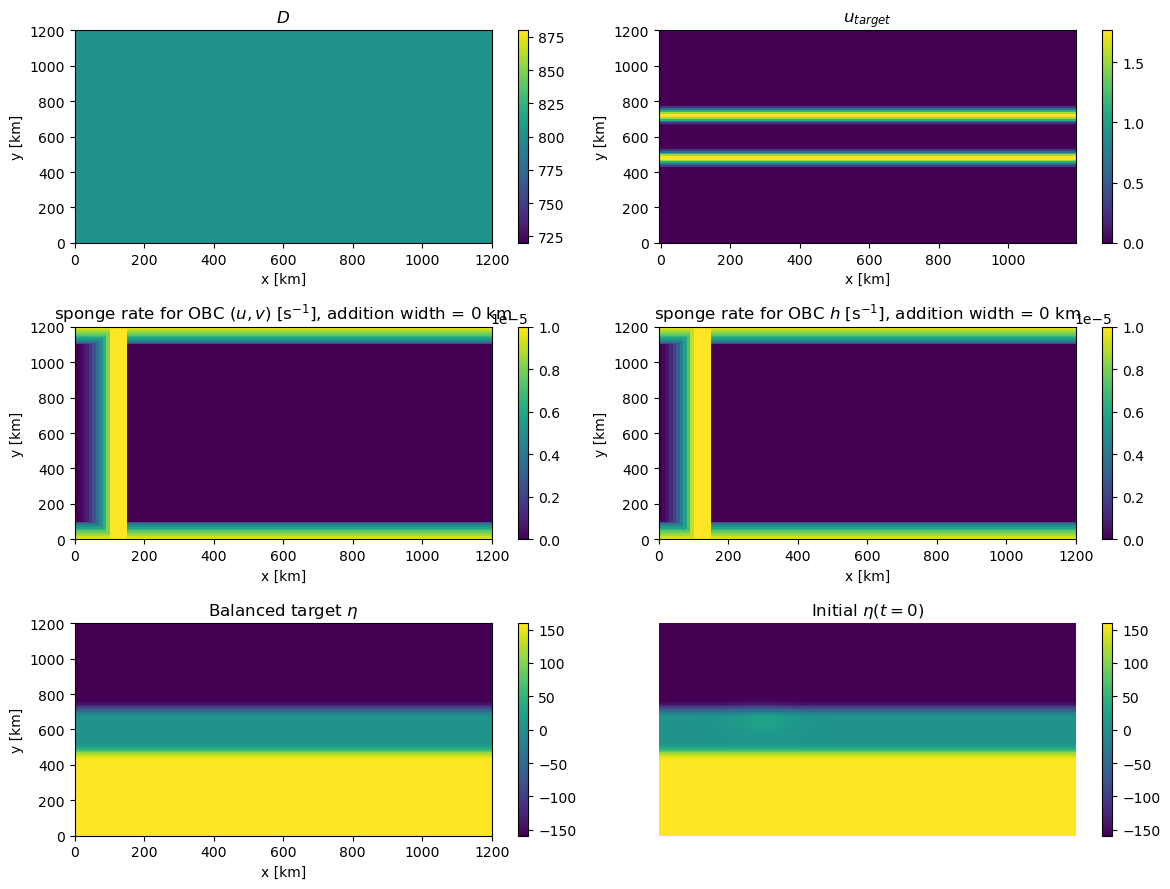

In [13]:
# Barotropic instability in a channel: a balanced zonal jet maintained by a
# localized western sponge (beta-plane).

# nj, ru_params = [dt, steps/segment, segments]
# nj, run_params = 40, [200., 500, 25]  # Barely permitted eddies
nj, run_params = 120, [200., 500, 100]  # Coarsest resolution with good instabilities
# nj, run_params = 120, [50., 2000, 100]  # Finer resolution
# nj, run_params = 180, [5., 5000, 100]  # Finer resolution is very unstable

M = SSWEM(nj,
          0.08,    # Gravity [m s-2]
          800.,    # Nominal layer thickness [m]
          1200.e3,  # Domain width [m]  (50% longer in x than y)
          1.e-4,   # Coriolis [s-1]
          3.0e-11, # df/dy [m-1 s-1]  (beta-plane arrests the large-scale meridional mode)
          2.5e-5,  # Bottom drag rate [m s-1]
          2e2,     # Lateral viscosity [m2 s-1]
          nj=nj    # Rectangular channel
          )
# M.D[0,:] = 0       # dry rows N/S -> zonal channel walls
# M.D[-1,:] = 0

# Target zonal jet and its geostrophically balanced free surface (f u = -g d(eta)/dy)
# M.set_u_target_jet(1.0)                            # u_target = jet(y)

# Double jet
yc = M.yu / M.Ly                                   # non-dim y at u-points
hw = 60e3 / M.Ly                                   # half-width of each jet (< Ly/6 so they don't overlap)
bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)
profile = 1.8 * (bump(2/5) + bump(3/5))                   # two eastward jets at y = 2Ly/5, 3Ly/5
M.u_target = np.empty_like(M.u)
for k in range(M.nk):
    M.u_target[k, :] = 1.0 * profile               # 1.0 = peak speed [m/s]


uy  = M.u_target[0].mean(axis=1)                   # u(y)
f_h = M.fo + M.beta * M.yh1                        # f(y) at row centres
eta = -(1.0/M.g[0]) * np.cumsum(f_h * uy) * M.dy
eta -= eta.mean() # Why remove mean? 
hbal = np.maximum(M.D + eta[:, None], 0.0)         # balanced thickness
hbal[0, :] = hbal[1, 1]
hbal[-1, :] = hbal[-2, 1]

# ============================= Sponge Layer Setup ==============================================

# Sponges restoring u->jet, v->0, h->balanced: a western sponge over the westernmost
# 150 km, plus N/S near-wall sponges over the outer 100 km.
# Local forcing only; the rest of the domain is free to evolve.
factor = 1.5
def ramp(x, x0, Lx, p=0.5): return np.clip((x - x0)/(Lx - x0), 0, 1)**p
def ramp2(x, x0, Lx, factor=1.5): return np.clip(factor*(x - x0)/(Lx - x0), 0, 1)**2
# rate, Lw, yb = 1.0e-5, 150.e3, 100e3               # western sponge width Lw; near-wall band yb
rate_h, rate_uv, Lw_uv, Lw_h, yb = 1.e-5, 1.e-5, 150.e3, 150.e3, 100e3

rate_h_ns = rate_h
rate_uv_ns = rate_uv

ratio_temp = 0
width = ratio_temp * Lw_uv
# width = 0.e3
# width = 50.e3 # The additional width of the sponge layer

# Western sponge: the eastern ramp shifted to [0, Lw + d] -- same W->E rise (0 at x=0 up to
# the max), then masked to 0 beyond Lw so it drops discontinuously to 0 at x=Lw + d

# Modified here, Lw + d
M.u_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xu, 0., Lw_uv) * (M.xu < Lw_uv + width), ramp(M.yu, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) )
M.v_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xv, 0., Lw_uv) * (M.xv < Lw_uv + width), ramp(M.yv, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) )
M.h_relax  = rate_h * np.maximum( np.maximum( ramp2(M.xh, 0., Lw_uv) * (M.xh < Lw_uv + width), ramp(M.yh, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) )
M.h_target = hbal[None, :, :].copy()               # u_target/v_target already set (jet / 0)

#====================================== END

# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[0] = M.u_target[0].copy()
M.h[0] = hbal.copy()
M.perturb_h(20., 0.05 * M.Lx, 3.e5, 0.55 * M.Ly)

# Setup diagnostics
fig, ax = plt.subplots(3, 2, figsize=(12, 9))
cs = ax[0,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.D ); fig.colorbar(cs, ax=ax[0,0]); ax[0,0].set_title(r'$D$');
cs = ax[0,1].pcolormesh( M.xq1/1e3, M.yh1/1e3, M.u_target[0] ); fig.colorbar(cs, ax=ax[0,1]); ax[0,1].set_title(r'$u_{target}$');
cs = ax[1,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.u_relax[0] ); fig.colorbar(cs, ax=ax[1,0]); ax[1,0].set_title(f'sponge rate for OBC ($u,v$) [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[1,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.h_relax[0] ); fig.colorbar(cs, ax=ax[1,1]); ax[1,1].set_title(f'sponge rate for OBC $h$ [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[2,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, hbal - M.D ); fig.colorbar(cs, ax=ax[2,0]); ax[2,0].set_title(r'Balanced target $\eta$');
cs = ax[2,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=ax[2,1]); ax[2,1].set_title(r'Initial $\eta(t=0)$');
ax[2,1].axis('off')                                # no sixth panel
for a in (ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]):
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout();

In [14]:
n_bc    = 15 # [OBC] number of prescribed Western boundary. 
i_edge  = np.where(M.xh1 < Lw_uv + width)[0].max()                
west_cols = np.arange(i_edge - n_bc + 1, i_edge + 1)                 
print(f'[OBC] {n_bc} boundary columns i = {list(west_cols)},  '
      f"x = {np.round(M.xh1[west_cols]/1e3, 1)} km")
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)         

[OBC] 15 boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)],  x = [  5.  15.  25.  35.  45.  55.  65.  75.  85.  95. 105. 115. 125. 135.
 145.] km


Rayleigh-Kuo (beta - U_yy) changes sign in interior: True


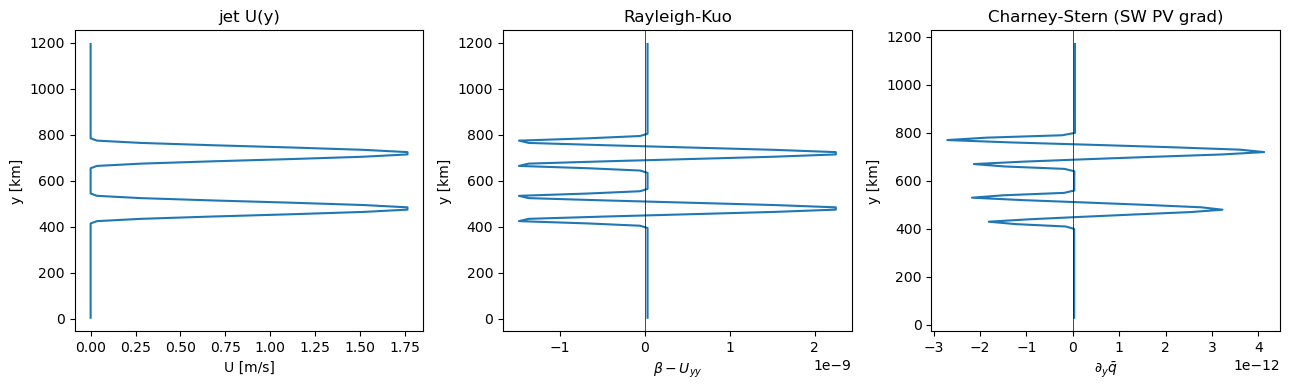

In [15]:
# Barotropic-instability criterion (Rayleigh-Kuo / Charney-Stern): a NECESSARY
# condition for instability is that the background potential-vorticity gradient
# changes sign in the interior. Evaluated on the initial balanced jet.
# See https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Kuo_criterion

U   = M.u[0].mean(axis=1)                          # U(y)
Uyy = np.gradient(np.gradient(U, M.yh1), M.yh1)
RK  = M.beta - Uyy                                 # Rayleigh-Kuo (non-divergent barotropic)
dqdy = np.gradient(M.q(k=0).mean(axis=1), M.yq1)   # Charney-Stern: d/dy of zonal-mean SW PV
dqdy[:3] = np.nan                                  # mask near-wall rows where h->0 makes
dqdy[-2:] = np.nan                                 # q=(f+zeta)/h spike and swamp the interior

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(U, M.yh1/1e3);    ax[0].set_xlabel('U [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('jet U(y)')
ax[1].plot(RK, M.yh1/1e3);   ax[1].axvline(0, color='k', lw=0.5); ax[1].set_xlabel(r'$\beta - U_{yy}$'); ax[1].set_ylabel('y [km]'); ax[1].set_title('Rayleigh-Kuo')
ax[2].plot(dqdy, M.yq1/1e3); ax[2].axvline(0, color='k', lw=0.5); ax[2].set_xlabel(r'$\partial_y \bar{q}$'); ax[2].set_ylabel('y [km]'); ax[2].set_title('Charney-Stern (SW PV grad)')
fig.tight_layout()
# With the near-wall spike masked, the interior sign change in the SW PV gradient is
# visible in the Charney-Stern panel; the Rayleigh-Kuo panel is the cleaner read.

jj = (M.yh1/M.Ly > 0.12) & (M.yh1/M.Ly < 0.88)     # interior (skip dry walls)
print('Rayleigh-Kuo (beta - U_yy) changes sign in interior:', bool((RK[jj].min() < 0) and (RK[jj].max() > 0)))

# Control Run, Generate Input   

Run the Control run here to generate training input data. Need three columns including the open boundary column for training. 

To provide more training input, multiple columns are picked as open boundary. Each correspond to its own input data. All data are generated through one run. 

In [16]:
# [OBC - Orlanski] Control run -> training-data probe.

b_obc    = M.ni - 1 - 20                        # primary OBC col (=99); kept for the Sim3 demo cells below
ext_cols = np.array([b_obc + 1, b_obc + 2])

# Set of Different Open Boundary Location
band_w     = 8                                 
probe_hi   = int(b_obc)                        
probe_lo   = probe_hi - band_w + 1       

b_obc_list = np.arange(probe_lo + 2, probe_hi + 1)  

# Ensure we can refer the open boundary index using its true index in the simulation. 
icol       = lambda c: int(c) - probe_lo       

print(f'[NN-DATA] probe band i = {probe_lo}..{probe_hi} ({band_w} cols);  '
      f'{len(b_obc_list)} OBC locations i = {list(b_obc_list)}  '
      f'(x = {np.round(M.xh1[b_obc_list]/1e3,0)} km)')

pres_cols = np.concatenate([west_cols])
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)

u, v, h, time, h_bc_all, u_bc_all, v_bc_all, probe_band = M.run_record_bc(
    *run_params, pres_cols,
    store_downstream=True, probe_i0=probe_lo, n_probe=band_w)   


# Generate the 
tri_sl = slice(band_w - 3, band_w)              # [NN-DATA] last 3 band cols = [b_obc-2, b_obc-1, b_obc] (view, no copy)
probe = {'cols': np.array([b_obc - 2, b_obc - 1, b_obc]),
         'x_km': M.xh1[b_obc - 2:b_obc + 1] / 1e3,
         'h': probe_band['h'][..., tri_sl],
         'u': probe_band['u'][..., tri_sl],
         'v': probe_band['v'][..., tri_sl]}

# These are the columns for external forcing (index 2 = column b_obc; unchanged)
h_ext_all = probe['h'][:, :, :, 2]
v_ext_all = probe['v'][:, :, :, 2]
u_ext_all = probe['u'][:, :, :, 2]

[NN-DATA] probe band i = 92..99 (8 cols);  6 OBC locations i = [np.int64(94), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.int64(99)]  (x = [945. 955. 965. 975. 985. 995.] km)
numba threads = 16
CFL: dt*f = 0.027139999999999997
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 50000
Time: Trun * fo = 1000.0
Time: Trun * ( cg / L ) = 66.66666666666667
[OBC] recording (u,v,h) at boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
[OBC] also storing downstream probe at columns i = 92..99
Running (record)...
...done


In [17]:
print(b_obc_list)
print(probe_band['h'].shape)
print(icol)

[94 95 96 97 98 99]
(50000, 1, 120, 8)
<function <lambda> at 0x0000026BCDBE97E0>


# Plots and Animations

In [18]:
# # Snapshot
# fig, axs = plt.subplots(2, 2, figsize=(12, 9))
# cs = axs[0,0].contourf( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=axs[0,0]); axs[0,0].set_title(r"$\eta$");
# cs = axs[0,1].contourf( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) - (M.h_target[0] - M.D) ); fig.colorbar(cs, ax=axs[0,1]); axs[0,1].set_title(r"$\eta' = \eta - \eta_{targ}$");
# cs = axs[1,0].contourf( M.xq1/1e3, M.yq1/1e3, M.abs_omega(k=0) ); fig.colorbar(cs, ax=axs[1,0]); axs[1,0].set_title(r'$f + \partial_x v - \partial_y u$');
# cs = axs[1,1].contourf( M.xq1/1e3, M.yq1[2:-2]/1e3, M.q(h=h[-1], u=u[-1], v=v[-1], k=0)[2:-2,:] ); fig.colorbar(cs, ax=axs[1,1]); axs[1,1].set_title(r'$q$');
# for a in axs.ravel():
#     a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
# fig.tight_layout();

In [19]:
# # Plot time series
# fig,ax = plt.subplots(1,3,figsize=(12,5))
# ax[0].plot( time/86400, (h - M.D).min(axis=(1,2,3)), label=r'min($\eta$)' )
# ax[0].plot( time/86400, (h - M.D).max(axis=(1,2,3)), label=r'max($\eta$)' )
# ax[0].set_xlabel('time [days]'); ax[0].set_ylabel(r'$\eta$ [m]'); ax[0].set_title('surface-height extrema'); ax[0].legend();
# ax[1].plot( time/86400, u.max(axis=(1,2,3)), label='max(u)' )
# ax[1].plot( time/86400, u.min(axis=(1,2,3)), label='min(u)' )
# ax[1].plot( time/86400, v.max(axis=(1,2,3)), '--', label='max(v)' )
# ax[1].plot( time/86400, v.min(axis=(1,2,3)), '--', label='min(v)' )
# ax[1].set_xlabel('time [days]'); ax[1].set_ylabel('velocity [m/s]'); ax[1].set_title('velocity extrema'); ax[1].legend();
# ax[2].plot( time/86400, M.KE(h=h, u=u, v=v).sum(axis=(1,2,3)), label='KE' )
# ax[2].set_xlabel('time [days]'); ax[2].set_ylabel(r'KE [m$^3$ $\text{s}^{-2}$]'); ax[2].set_title('domain-summed kinetic energy'); ax[2].legend();
# fig.tight_layout();

In [20]:
# # Animate
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# fig, ax = plt.subplots()
# # Compute PV for all time levels
# pv = np.array([M.q(h=h[n], u=u[n], v=v[n], k=0) for n in range(len(time))])
# # pv[:,:3,:] = 1e-7
# # pv[:,-2:,:] = 1e-7

# # Use consistent color limits across frames
# vmin, vmax = pv.min(), pv.max()
# cf = ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[-1], levels=20, vmin=vmin, vmax=vmax)
# cb = fig.colorbar(cf)
# ax.axvline(150, color='k', ls=':', lw=1)              # sponge edge: free model is east of x=150 km
# ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
# title = ax.set_title(f'$q$ at t = {time[0]/86400:.2f} days')

# def update(n):
#     ax.clear()
#     ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[n], levels=20, vmin=vmin, vmax=vmax)
#     ax.axvline((Lw_uv +ratio_temp * Lw_uv)/1e3, color='k', ls=':', lw=1)          # sponge edge (ax.clear wipes it)
#     ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')  # restore labels (ax.clear wipes them)
#     ax.set_title(f'$q$ at t = {time[n]/86400:.2f} days')

# anim = FuncAnimation(fig, update, frames=len(time), interval=100)
# anim.save('pv_evolution.gif', writer='pillow', fps=10, dpi=100)   # save GIF (no ffmpeg needed)
# plt.close(fig)
# HTML(anim.to_jshtml())

# Pack and Normalization

Generate the training input. 

For each open boundary points, in total of 8 stencil value are needed to update it. 

| idx | grid point | time | notes |
| :---: | :---: | :---: | :--- |
| 0 | (b-1, j-1) | n | |
| 1 | (b-1, j) | n | |
| 2 | (b-1, j+1) | n | |
| 3 | (b, j-1) | n | |
| 4 | (b, j) | n | phi_prev_b (update law) |
| 5 | (b, j+1) | n | |
| 6 | (b-1, j) | n+1 | pim1 (update law) |
| 7 | (b-2, j) | n+1 | pim2 (network only) |

Here j is periodic. 


In [21]:
# Pack the Data
FIELDS     = ('h', 'u', 'v')
field_code = {'h': 0, 'u': 1, 'v': 2}

# Sample only 1 steps every 'stride' time step, reduce the training input size. 
stride = 50                                    
# Total number of time steps
nstep  = probe_band['h'].shape[0]

n0     = np.arange(0, nstep - 1, stride)        # step n  (partner n+1 = n0+1, the consecutive step)
jm = lambda A: np.roll(A,  1, axis=-1)          # (.., j-1)   (matches jm = j-1 in the scheme)
jp = lambda A: np.roll(A, -1, axis=-1)          # (.., j+1)

# P is the field, b is the obc location
def _pack(P, b):
    """P: band probe field (nstep,nk,nj,band_w) -> (X_raw (Ns,8), label (Ns,))."""
    Pb, Pbm1, Pbm2 = P[..., icol(b)], P[..., icol(b - 1)], P[..., icol(b - 2)]   # (nstep,nk,nj)
    Pb_n,  Pbm1_n            = Pb[n0],   Pbm1[n0]                                # step n
    Pb_n1, Pbm1_n1, Pbm2_n1 = Pb[n0+1], Pbm1[n0+1], Pbm2[n0+1]                   # step n+1
    feats = np.stack([jm(Pbm1_n), Pbm1_n, jp(Pbm1_n),     # 0,1,2 : (b-1, j-1/j/j+1) @ n
                      jm(Pb_n),   Pb_n,   jp(Pb_n),       # 3,4,5 : (b,   j-1/j/j+1) @ n
                      Pbm1_n1, Pbm2_n1], axis=-1)         # 6,7   : pim1, pim2 @ n+1
    return feats.reshape(-1, 8), Pb_n1.reshape(-1)

Xr, yy, fid, lid, bid = [], [], [], [], []
lay_tile = np.tile(np.repeat(np.arange(M.nk), M.nj), len(n0))   # layer index per flattened (n,k,j)
for b in b_obc_list:
    for fn in FIELDS:
        Xb, yb = _pack(probe_band[fn], int(b))
        Xr.append(Xb); yy.append(yb)
        fid.append(np.full(yb.shape, field_code[fn], np.int64))
        lid.append(lay_tile.copy())
        bid.append(np.full(yb.shape, int(b), np.int64))



In [22]:
X_raw    = np.concatenate(Xr).astype(np.float32)   # (N,8) raw physical stencil (feeds the update law)
y        = np.concatenate(yy).astype(np.float32)   # (N,)  label = control@b @ n+1
phi_ext  = y.copy()                                # [NN-DATA] inflow target (== label in teacher forcing)
field_id = np.concatenate(fid)                     # (N,) 0/1/2 = h/u/v
layer_id = np.concatenate(lid)                     # (N,) layer k
loc_id   = np.concatenate(bid)                     # (N,) OBC column b (provenance / train-val split)
print(f'[NN-DATA] packed {X_raw.shape[0]:,} samples  '
      f'({len(b_obc_list)} loc x {len(FIELDS)} fields x {len(n0)} step-pairs x {M.nk*M.nj} pts)')

[NN-DATA] packed 2,160,000 samples  (6 loc x 3 fields x 1000 step-pairs x 120 pts)


# Normalization

Two methods of normalization are implemented

1. Robust : Use the difference between 75 quaentils and 25 quaentiles as the sclae
2. Min-max : Use difference between max and min as scale. 

If the sample happens to be constant, both scales generate a scale of 0, which is unrealistic, in this case just assign the scale to be 1.0. (Question about this patr)

We do a per-sample normalization because the phase velocity $c_x, c_y$ are dimensionless. So it doesn't matter that different sample uses different scale. 

In [ ]:
# 0 = robust (median/IQR), 1 = min-max -- applied PER SAMPLE
norm_mode = 1        

# ---- per-sample stats over the 8 stencil values (axis=1) ----
if norm_mode == 1:
    min = X_raw.min(axis=1, keepdims=True)               
    scale_s  = X_raw.max(axis=1, keepdims=True) - min     
else:
    center_s = np.median(X_raw, axis=1, keepdims=True)         # (N,1) per-sample median
    quas       = np.percentile(X_raw, [75, 25], axis=1)          # (2,N)
    scale_s  = (quas[0] - quas[1])[:, None]                         # (N,1) per-sample IQR

scale_s = np.where(scale_s <= 0, 1.0, scale_s).astype(np.float32)   # guard constant samples
X_norm  = ((X_raw - center_s) / scale_s).astype(np.float32)         # (N,8) per-sample normalized
sample_scale = scale_s[:, 0]                                        # (N,) per-sample scale (for the plot)

# ---- per-VARIABLE GLOBAL scale (old approach), for comparison ONLY ----
def _global_scale(v):                                          # v: all pooled values of one field
    if norm_mode == 1:
        rng = float(np.max(v) - np.min(v)); return rng if rng > 0 else 1.0
    iqr = float(np.subtract(*np.percentile(v, [75, 25]))); return iqr if iqr > 0 else (float(np.std(v)) or 1.0)
glob_scale = np.array([_global_scale(X_raw[field_id == c]) for c in (0, 1, 2)], np.float32)
print(f"[NN-DATA] per-sample normalization ({'min-max' if norm_mode == 1 else 'robust'});  "
      f"per-variable global scale = {np.round(glob_scale, 4)}")

# network input = [ 8 normalized values | field one-hot(3) | layer ]
field_oh = np.eye(3, dtype=np.float32)[field_id]
X_net    = np.concatenate([X_norm, field_oh, layer_id.astype(np.float32)[:, None]], axis=1)  # (N,12)
print(f'[NN-DATA] X_net {X_net.shape} | X_raw {X_raw.shape} | y {y.shape}')

np.savez_compressed('nn_obc_training_data.npz',
    X_net=X_net, X_raw=X_raw, y=y, phi_ext=phi_ext,
    field_id=field_id, layer_id=layer_id, loc_id=loc_id,
    norm_mode=norm_mode, glob_scale=glob_scale)
print('[NN-DATA] saved -> nn_obc_training_data.npz')

[NN-DATA] per-sample normalization (robust);  per-variable global scale = [2.362835e+02 6.059000e-01 9.980000e-02]
[NN-DATA] X_net (2160000, 12) | X_raw (2160000, 8) | y (2160000,)
[NN-DATA] saved -> nn_obc_training_data.npz


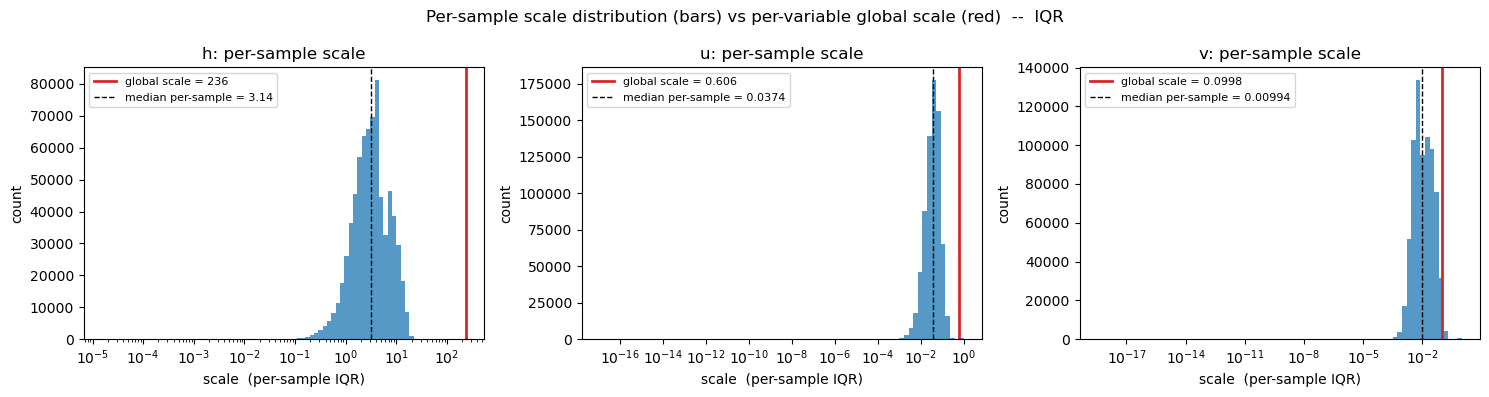

In [26]:
# [NN-DATA] Compare the PER-SAMPLE scale (one per sample, bars) against the single
# PER-VARIABLE GLOBAL scale (red line). If per-sample scales span orders of magnitude,
# the global scale cannot represent all samples -- that is the motivation for per-sample.
scale_kind = 'range' if norm_mode == 1 else 'IQR'
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for c, fn in enumerate(FIELDS):
    s = sample_scale[field_id == c]
    s = s[s > 0]                                              # drop guarded (constant) samples
    bins = np.logspace(np.log10(s.min()), np.log10(s.max()), 80)
    ax[c].hist(s, bins=bins, color='C0', alpha=0.75)
    ax[c].axvline(glob_scale[c], color='C3', lw=2, label=f'global scale = {glob_scale[c]:.3g}')
    ax[c].axvline(np.median(s),  color='k', ls='--', lw=1, label=f'median per-sample = {np.median(s):.3g}')
    ax[c].set_xscale('log')
    ax[c].set_title(f'{fn}: per-sample scale')
    ax[c].set_xlabel(f'scale  (per-sample {scale_kind})'); ax[c].set_ylabel('count'); ax[c].legend(fontsize=8)
fig.suptitle(f'Per-sample scale distribution (bars) vs per-variable global scale (red)  --  {scale_kind}')
fig.tight_layout()

# Neural Network

The network **replaces the analytic phase-speed estimate** `(cx, cy)` of the east-Orlanski
scheme. Everything physical — the radiation update and the inflow nudge — stays in the
differentiable helper `orlanski_east_update`. The net never sees `alpha_in` and does **not**
decide inflow/outflow.

**Data flow (per sample):**

```
X_net (12) ─► OBCNet ─► (cx, cy)
                          │
X_raw (8) ────────────────┼─► orlanski_east_update(X_raw, cx, cy, inflow, phi_ext, alpha_in)
inflow (analytic) ────────┘                 │
                                        phi_b_pred ─► loss = mean[ ((phi_b_pred − y)/glob_scale[field])² ]
```

- **Input** `X_net` (12) = 8 per-sample-normalized stencil values + field one-hot(3) + layer.
  The raw physical `X_raw` is **not** fed to the net — it feeds the update law (physical units). 
  1. The one-hot here is a index for different variable. This is letting the Neural Network knows which variable it is working on. 
- **Architecture**: one shared MLP `12 → 32 → 32 → 2` (ReLU). Shared across h/u/v; the field
  one-hot lets it specialize without training three separate nets.
- **Outputs**: `cx = sigmoid(·) ∈ [0,1]` (keeps the `1/(1+cx)` denominator stable) and
  `cy = tanh(·) ∈ [-1,1]`. These differentiable squashes replace the analytic hard clamps so
  gradients survive at the rails.
- **inflow / outflow** is decided analytically by `orlanski_east_analytic` (the `rx<0` test),
  not by the net. On **outflow** the net's `(cx, cy)` radiate; on **inflow** the fixed
  `alpha_in` nudge is applied (no `cx, cy`). Its residual is included in the loss (**Option A**,
  all points) but carries no gradient to the net.
- **Loss** (Option A): `mean[ ((phi_b_pred − y)/glob_scale[field])² ]` over all points,
  per-field weighted so h (~100 m) and u, v (~0.1) contribute comparably.

In [ ]:
torch.manual_seed(0)
device = torch.device('cpu')


class OBCNet(nn.Module):
    """Predict (cx, cy) from X_net (..., 12) = [8 normalized stencil | field one-hot(3) | layer].
    cx = sigmoid -> [0,1] (keeps 1/(1+cx) stable);  cy = tanh -> [-1,1].
    The net does NOT decide inflow/outflow and never sees alpha_in -- those live in the helper.
    """
    def __init__(self, n_in=12, hidden=(32, 32)):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(d, 2)                     # -> (cx_raw, cy_raw)

    def forward(self, x):
        z  = self.head(self.body(x))
        cx = torch.sigmoid(z[..., 0])                   # [0,1]
        cy = torch.tanh(z[..., 1])                      # [-1,1]
        return cx, cy


net = OBCNet().to(device)
print(net)
print('trainable params:', sum(p.numel() for p in net.parameters()))

# sanity check on a small batch from the packed data (X_net built in the normalization cell)
xb = torch.as_tensor(X_net[:4], dtype=torch.float32, device=device)
cx, cy = net(xb)
print('cx', tuple(cx.shape), cx.min().item(), cx.max().item(),
      '| cy', tuple(cy.shape), cy.min().item(), cy.max().item())